# Reddit Community Engagement Analysis

Analyzed **4.5 million Reddit posts** across 35 tags to identify which topics consistently generate engagement, which popular topics underperform, and how language patterns differ between high and low scoring posts.

High-scoring posts are not random — they cluster around specific topics and show clear differences in wording and structure compared to low-scoring posts.

---

# Problem Statement

Community platforms generate millions of posts every day, but only a small fraction gets real engagement. Knowing which topics perform well on average is not enough — you need to know which ones perform *reliably*, which popular topics are actually underperforming, and what kind of language drives higher scores.

This analysis answers three questions:

- Which topics consistently get the highest engagement — not just on average, but reliably?
- Why do some popular topics get a lot of posts but very little reaction?
- What kind of language separates high-engagement posts from low ones?

---

# Why This Matters

- Helps community or content teams focus on topics that consistently perform, not just go viral once
- Identifies high-volume but low-engagement areas where effort is being wasted
- Shows how language and framing impact engagement, not just topic selection

---

# Dataset Overview

- **Source:** [Kaggle — Reddit Comments Labeled Data](https://www.kaggle.com/datasets/vaibhavsxn/reddit-comments-labeled-data)
- **Rows:** ~4.6 million
- **Columns:** score, body, Topic, Tag
- **Tags:** 35 categories
- **Topics:** 40 numeric IDs

Each row contains the post score, text, topic ID, and a human-readable tag.

---

# Analytical Approach

- Cleaned and deduplicated the full 4.5M dataset
- Used a validated 200K sample for efficient analysis without losing distribution patterns
- Studied engagement distribution to show why averages alone are misleading
- Focused only on tags with meaningful volume to avoid noisy conclusions
- Built a popularity vs engagement framework to separate strong, weak, and hidden opportunity topics
- Compared language patterns between high and low engagement posts to understand content differences

---

# Tools Used

- Python (Pandas, NumPy)
- Matplotlib & Seaborn
- Scikit-learn (CountVectorizer)
- Jupyter Notebook

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
df = pd.read_csv(r"new_tag_data.csv")
print(df.shape)
df.head()

(4594008, 4)


,score,body,Topic,Tag
0,5927,My boss is this giddy Asian lady (I work at a ...,30,Gender
1,5741,Once as a tired medical resident I was called ...,3,Teenage
2,5703,"You sound like me, I also started watching gay...",3,Teenage
3,5699,"It would be the inventor of punctuation, as he...",7,Social
4,5535,I got a call from my father's wife that he was...,3,Teenage


In [3]:
# Dataset structure and summary stats
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
df.info()
print("\n")
df.describe()

Shape: 4,594,008 rows × 4 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4594008 entries, 0 to 4594007
Data columns (total 4 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   score   int64 
 1   body    object
 2   Topic   int64 
 3   Tag     object
dtypes: int64(2), object(2)
memory usage: 140.2+ MB




,score,Topic
count,4.594008e+06,4.594008e+06
mean,6.295756e+00,1.589850e+01
std,5.728074e+01,1.063229e+01
min,-1.712000e+03,0.000000e+00
25%,1.000000e+00,7.000000e+00
50%,2.000000e+00,1.300000e+01
75%,3.000000e+00,2.600000e+01
max,5.927000e+03,3.900000e+01


## Dataset Structure

- ~4.6 million rows and 4 columns: score, body, Topic, and Tag.

- Score ranges from -1,712 to 5,927, but the median is just 2 — meaning most posts receive very low engagement. The gap between mean (6.3) and median (2) clearly shows a highly skewed distribution.

- Scores also include negative values (downvoted posts), which will be considered during analysis.

- The dataset uses ~140MB memory, so optimization and sampling are important for efficient processing.

In [4]:
# Store original row count
rows_before = len(df)

# Clean text columns first
df['body'] = df['body'].astype(str).str.strip()
df['Tag'] = df['Tag'].astype(str).str.strip().str.title()

# Remove rows where body or Tag is missing/empty
df = df[
    df['body'].notna() &
    df['Tag'].notna() &
    (df['body'] != '') &
    (df['Tag'] != '')
]

rows_after_text_cleaning = len(df)

# Fix numeric column types
df['score'] = pd.to_numeric(df['score'], errors='coerce')
df['Topic'] = pd.to_numeric(df['Topic'], errors='coerce')

# Drop rows where score or Topic could not be converted
df = df.dropna(subset=['score', 'Topic'])

# Convert numeric columns to integer type
df['score'] = df['score'].astype('Int64')
df['Topic'] = df['Topic'].astype('Int64')

rows_after_dtype_fix = len(df)

# Remove duplicate posts based on identical body text
duplicates_removed = df.duplicated(subset='body').sum()
df = df.drop_duplicates(subset='body')

rows_after_dedup = len(df)

# Optimize Tag column for memory and grouping speed
df['Tag'] = df['Tag'].astype('category')

# Summary
print(f"Rows before cleaning:      {rows_before:,}")
print(f"After text cleaning:       {rows_after_text_cleaning:,}")
print(f"After numeric fixes:       {rows_after_dtype_fix:,}")
print(f"Duplicates removed:        {duplicates_removed:,}")
print(f"Final clean rows:          {rows_after_dedup:,}")

Rows before cleaning:      4,594,008
After text cleaning:       4,594,008
After numeric fixes:       4,594,008
Duplicates removed:        217,924
Final clean rows:          4,376,084


## Data Cleaning

- Removed rows with missing or empty text, standardized tag names to title case, fixed numeric column types, and removed ~218K duplicate posts based on identical text content.

- The dataset reduced from ~4.59M to ~4.38M rows after cleaning. The Tag column was converted to categorical to improve memory efficiency and speed up grouping operations.

In [5]:
# Take a representative sample
sample = df.sample(n=200_000, random_state=42)

# Pre-compute stats (fast, no repeated filtering)
full_stats = df.groupby('Tag')['score'].agg(['mean', 'median'])
sample_stats = sample.groupby('Tag')['score'].agg(['mean', 'median'])

# Top 5 tags by frequency
top5_tags = df['Tag'].value_counts().head(5).index

# Print comparison
print("Sample Validation — Top 5 Tags\n")
print(f"{'Tag':<15} {'Full Mean':>10} {'Sample Mean':>12} {'Full Median':>12} {'Sample Median':>14}")
print("-" * 65)

for tag in top5_tags:
    print(f"{tag:<15} "
          f"{full_stats.loc[tag, 'mean']:>10.2f} "
          f"{sample_stats.loc[tag, 'mean']:>12.2f} "
          f"{full_stats.loc[tag, 'median']:>12.1f} "
          f"{sample_stats.loc[tag, 'median']:>14.1f}")

# Optional but strong: distribution check
print("\nTag distribution (Top 5):")
print(df['Tag'].value_counts(normalize=True).head(5))
print(sample['Tag'].value_counts(normalize=True).head(5))

# Summary
print(f"\nFull dataset: {len(df):,} rows")
print(f"Sample size:  {len(sample):,} rows")

Sample Validation — Top 5 Tags

Tag              Full Mean  Sample Mean  Full Median  Sample Median
-----------------------------------------------------------------
Teenage              10.38        10.58          2.0            2.0
Arg                   5.77         5.98          1.0            1.0
Work                  4.60         4.33          2.0            2.0
College               6.57         6.49          2.0            2.0
Tv                    5.39         5.11          1.0            1.0

Tag distribution (Top 5):
Tag
Teenage    0.103384
Arg        0.085967
Work       0.077761
College    0.058022
Tv         0.052751
Name: proportion, dtype: float64
Tag
Teenage    0.102705
Arg        0.086140
Work       0.078905
College    0.057480
Tv         0.052770
Name: proportion, dtype: float64

Full dataset: 4,376,084 rows
Sample size:  200,000 rows


## Sampling

- Working with 4.3M rows for every calculation is unnecessary. A 200,000 row sample is used and validated against the full dataset to ensure key patterns are preserved.

- The table above compares mean and median scores for the top 5 tags. The values are very close, showing the sample closely matches the full dataset.

- Median values remain almost identical, confirming the sample preserves the underlying skewed distribution. All further analysis is performed on this sample.

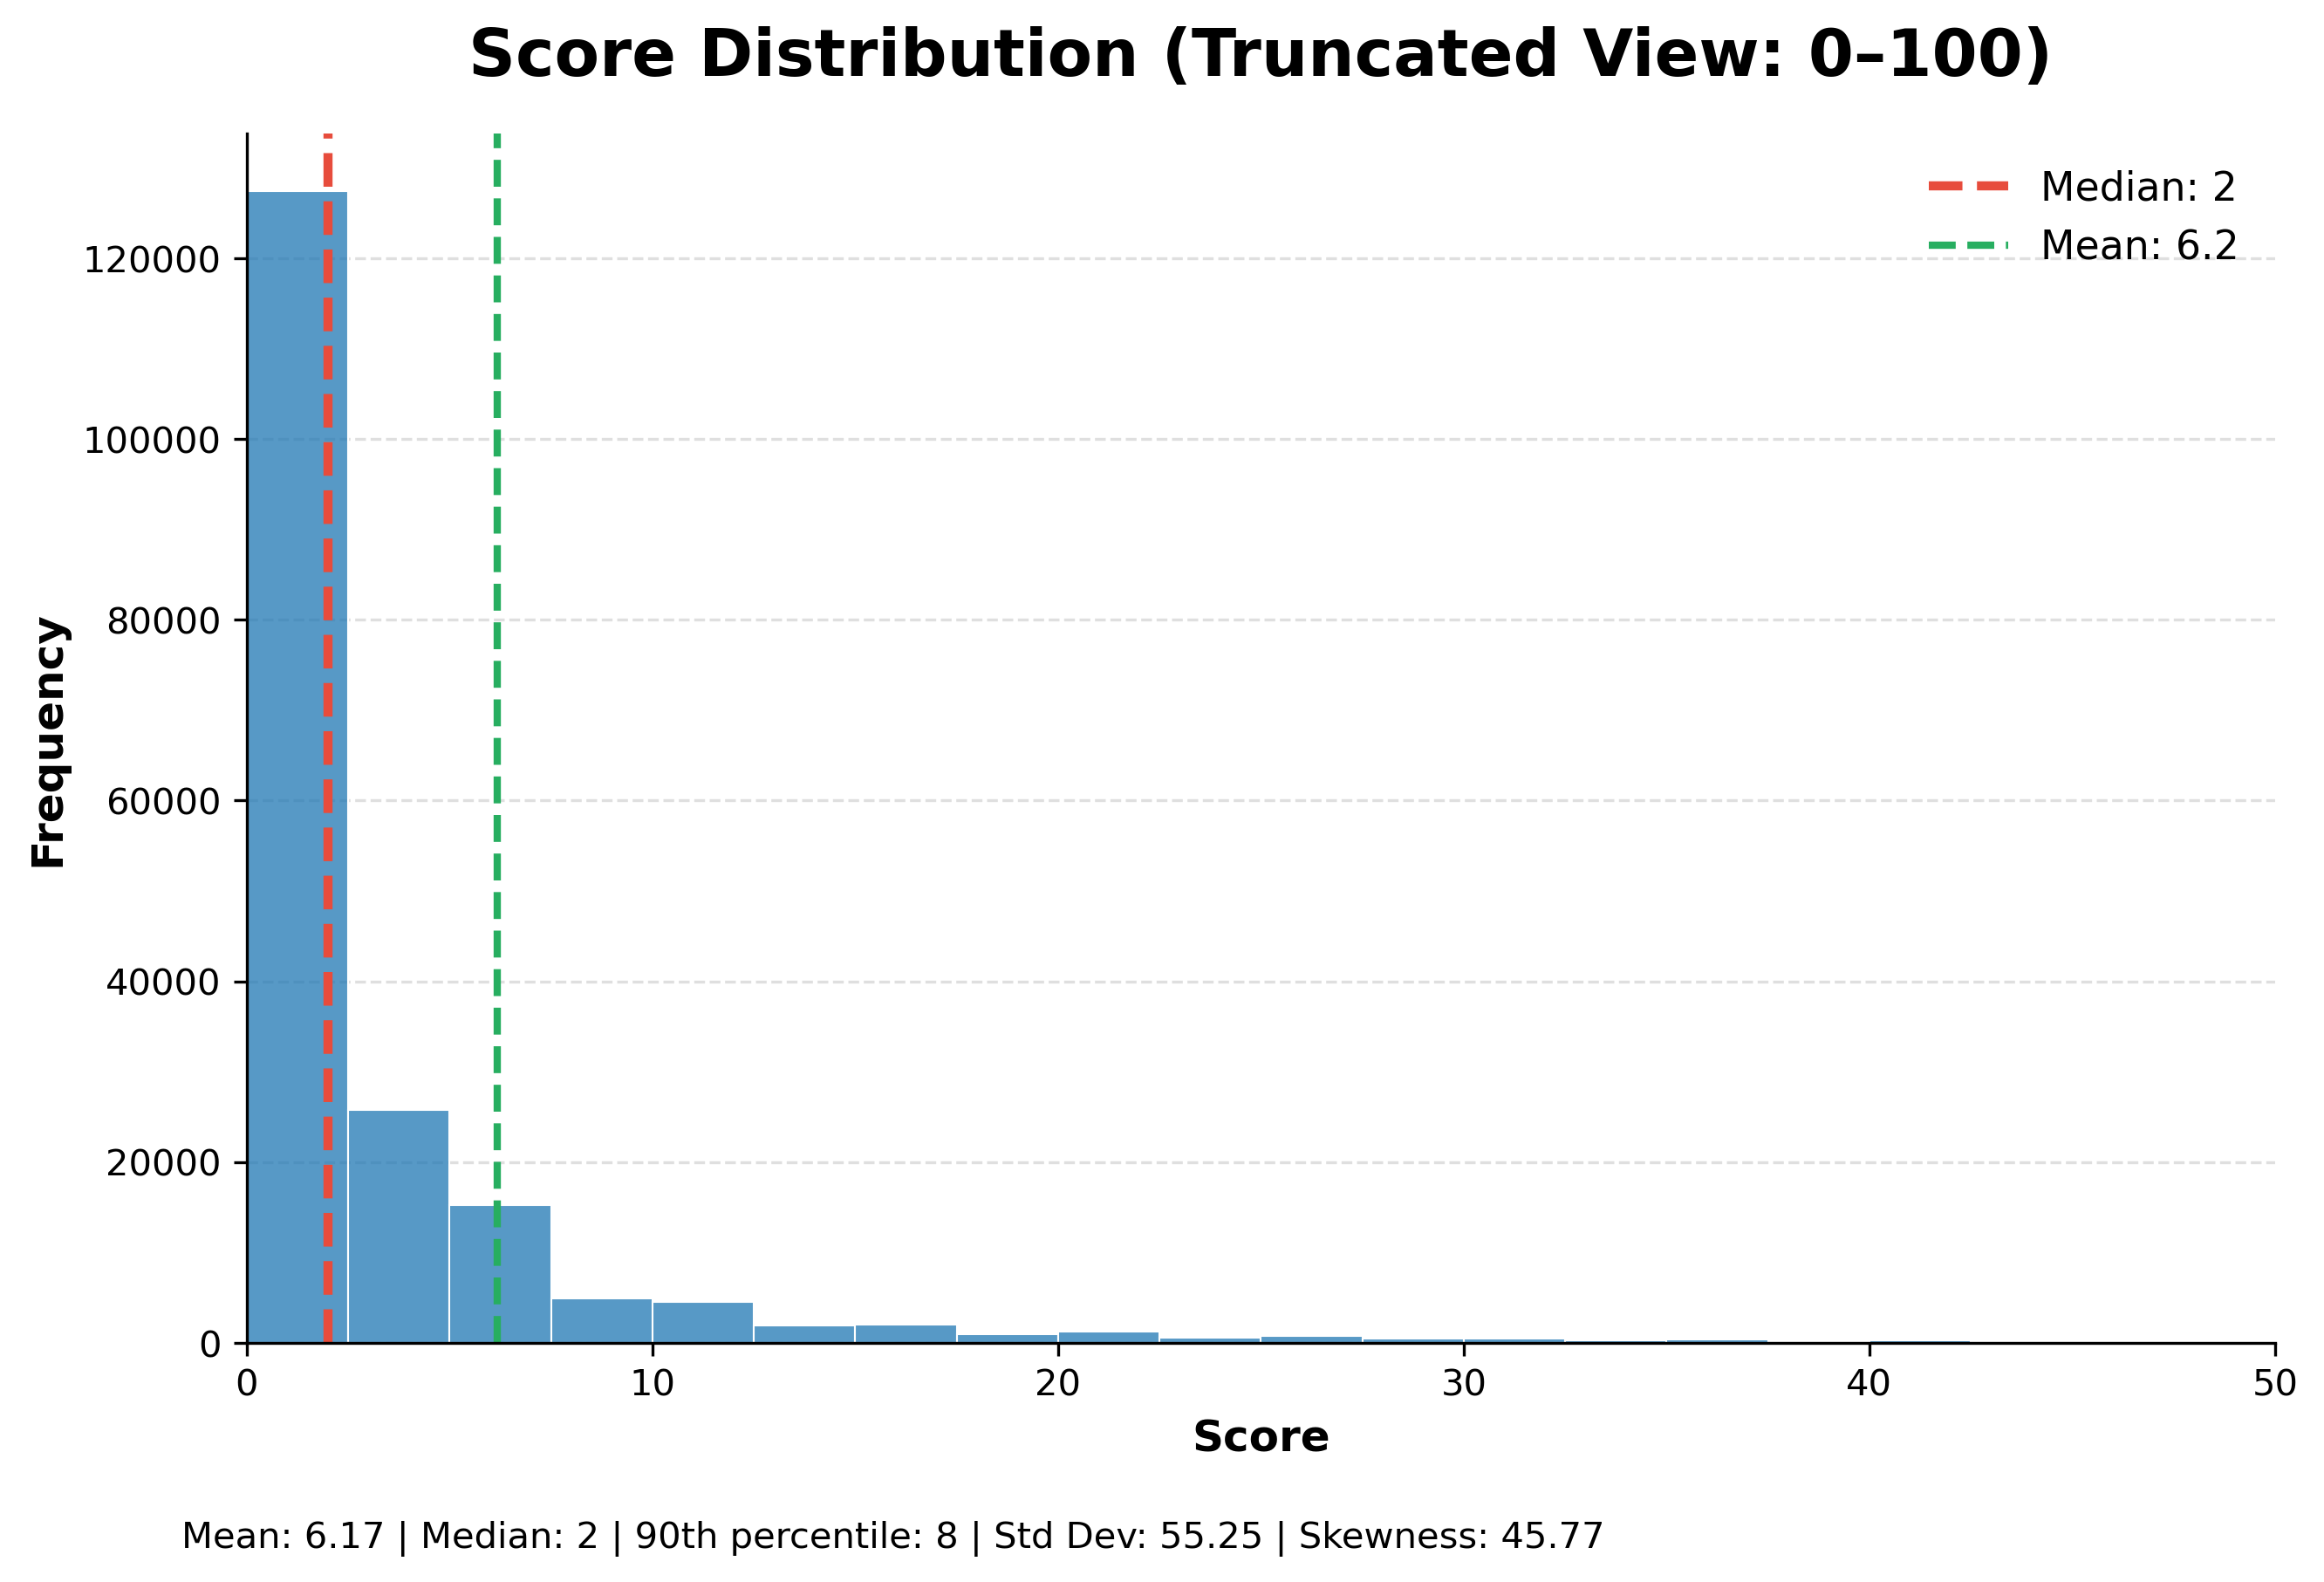

In [6]:
# Score distribution analysis
s = sample['score'].astype(float)

# Summary stats
mean_score = s.mean()
median_score = s.median()
p90_score = s.quantile(0.90)
std_score = s.std()
skew_score = s.skew()

# Truncated view for readability
plot_data = s[s.between(0, 100)]

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

sns.histplot(
    plot_data,
    bins=40,
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

# Mean and median lines
ax.axvline(median_score, linestyle='--', color='#e74c3c', linewidth=2.5, label=f'Median: {median_score:.0f}')
ax.axvline(mean_score, linestyle='--', color='#27ae60', linewidth=2, label=f'Mean: {mean_score:.1f}')

# Titles and labels
ax.set_title('Score Distribution (Truncated View: 0–100)', fontsize=18, fontweight='bold', pad=16)
ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_xlim(0, 50)

# Clean styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc='upper right', frameon=False, fontsize=11)

# Compact stats text
stats_text = (
    f"Mean: {mean_score:.2f} | "
    f"Median: {median_score:.0f} | "
    f"90th percentile: {p90_score:.0f} | "
    f"Std Dev: {std_score:.2f} | "
    f"Skewness: {skew_score:.2f}"
)

fig.text(0.10, -0.02, stats_text, fontsize=10)

fig.savefig('score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Score Distribution

- The score distribution is heavily right-skewed. The median score is much lower than the mean, which shows that a small number of viral posts pull the average upward.

- 90% of posts score 8 or below, so low engagement is the default. Skewness is also driven by extreme outliers beyond the 0–100 range, which are not fully visible in this chart.

Because of this, median is more reliable than mean for comparing engagement across tags in the next sections.

In [7]:
# Tag performance — only tags with 500+ posts in sample

tag_stats = sample.groupby('Tag')['score'].agg(
    post_count='count',
    mean_score='mean',
    median_score='median',
    iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
).reset_index()

# Filter for reliability
tag_stats = tag_stats[tag_stats['post_count'] >= 500]

# Sort: median first, mean as tie-breaker
tag_stats = tag_stats.sort_values(
    ['median_score', 'mean_score'],
    ascending=[False, False]
)

# Display top 10 only (clean view)
print(f"Tags with 500+ posts: {len(tag_stats)}\n")
tag_stats.head(10).round(2)

Tags with 500+ posts: 34



,Tag,post_count,mean_score,median_score,iqr
29,Teenage,20541,10.58,2.0,3.0
7,Gender,10341,8.68,2.0,4.0
12,International,7653,8.32,2.0,4.0
18,Nature,4842,8.06,2.0,3.0
20,Photography,2215,8.03,2.0,2.5
31,Treatment,3857,7.62,2.0,2.0
17,Music,4815,7.08,2.0,2.0
14,Media,1983,6.9,2.0,3.0
1,College,11496,6.49,2.0,2.0
27,Sports,2883,6.47,2.0,3.0


## Reliable High-Performing Tags

- Filtered to tags with at least 500 posts to avoid unreliable results from small groups. Tags are ranked by median score, with mean score used as a secondary factor when medians are similar.

- Most tags have a median score of 2, which shows that typical engagement is consistently low across topics. Differences between tags appear mainly in higher-end performance (mean score) and variability.

IQR (Interquartile Range) measures consistency:
- Lower IQR → more stable engagement
- Higher IQR → less predictable, with occasional high-performing posts

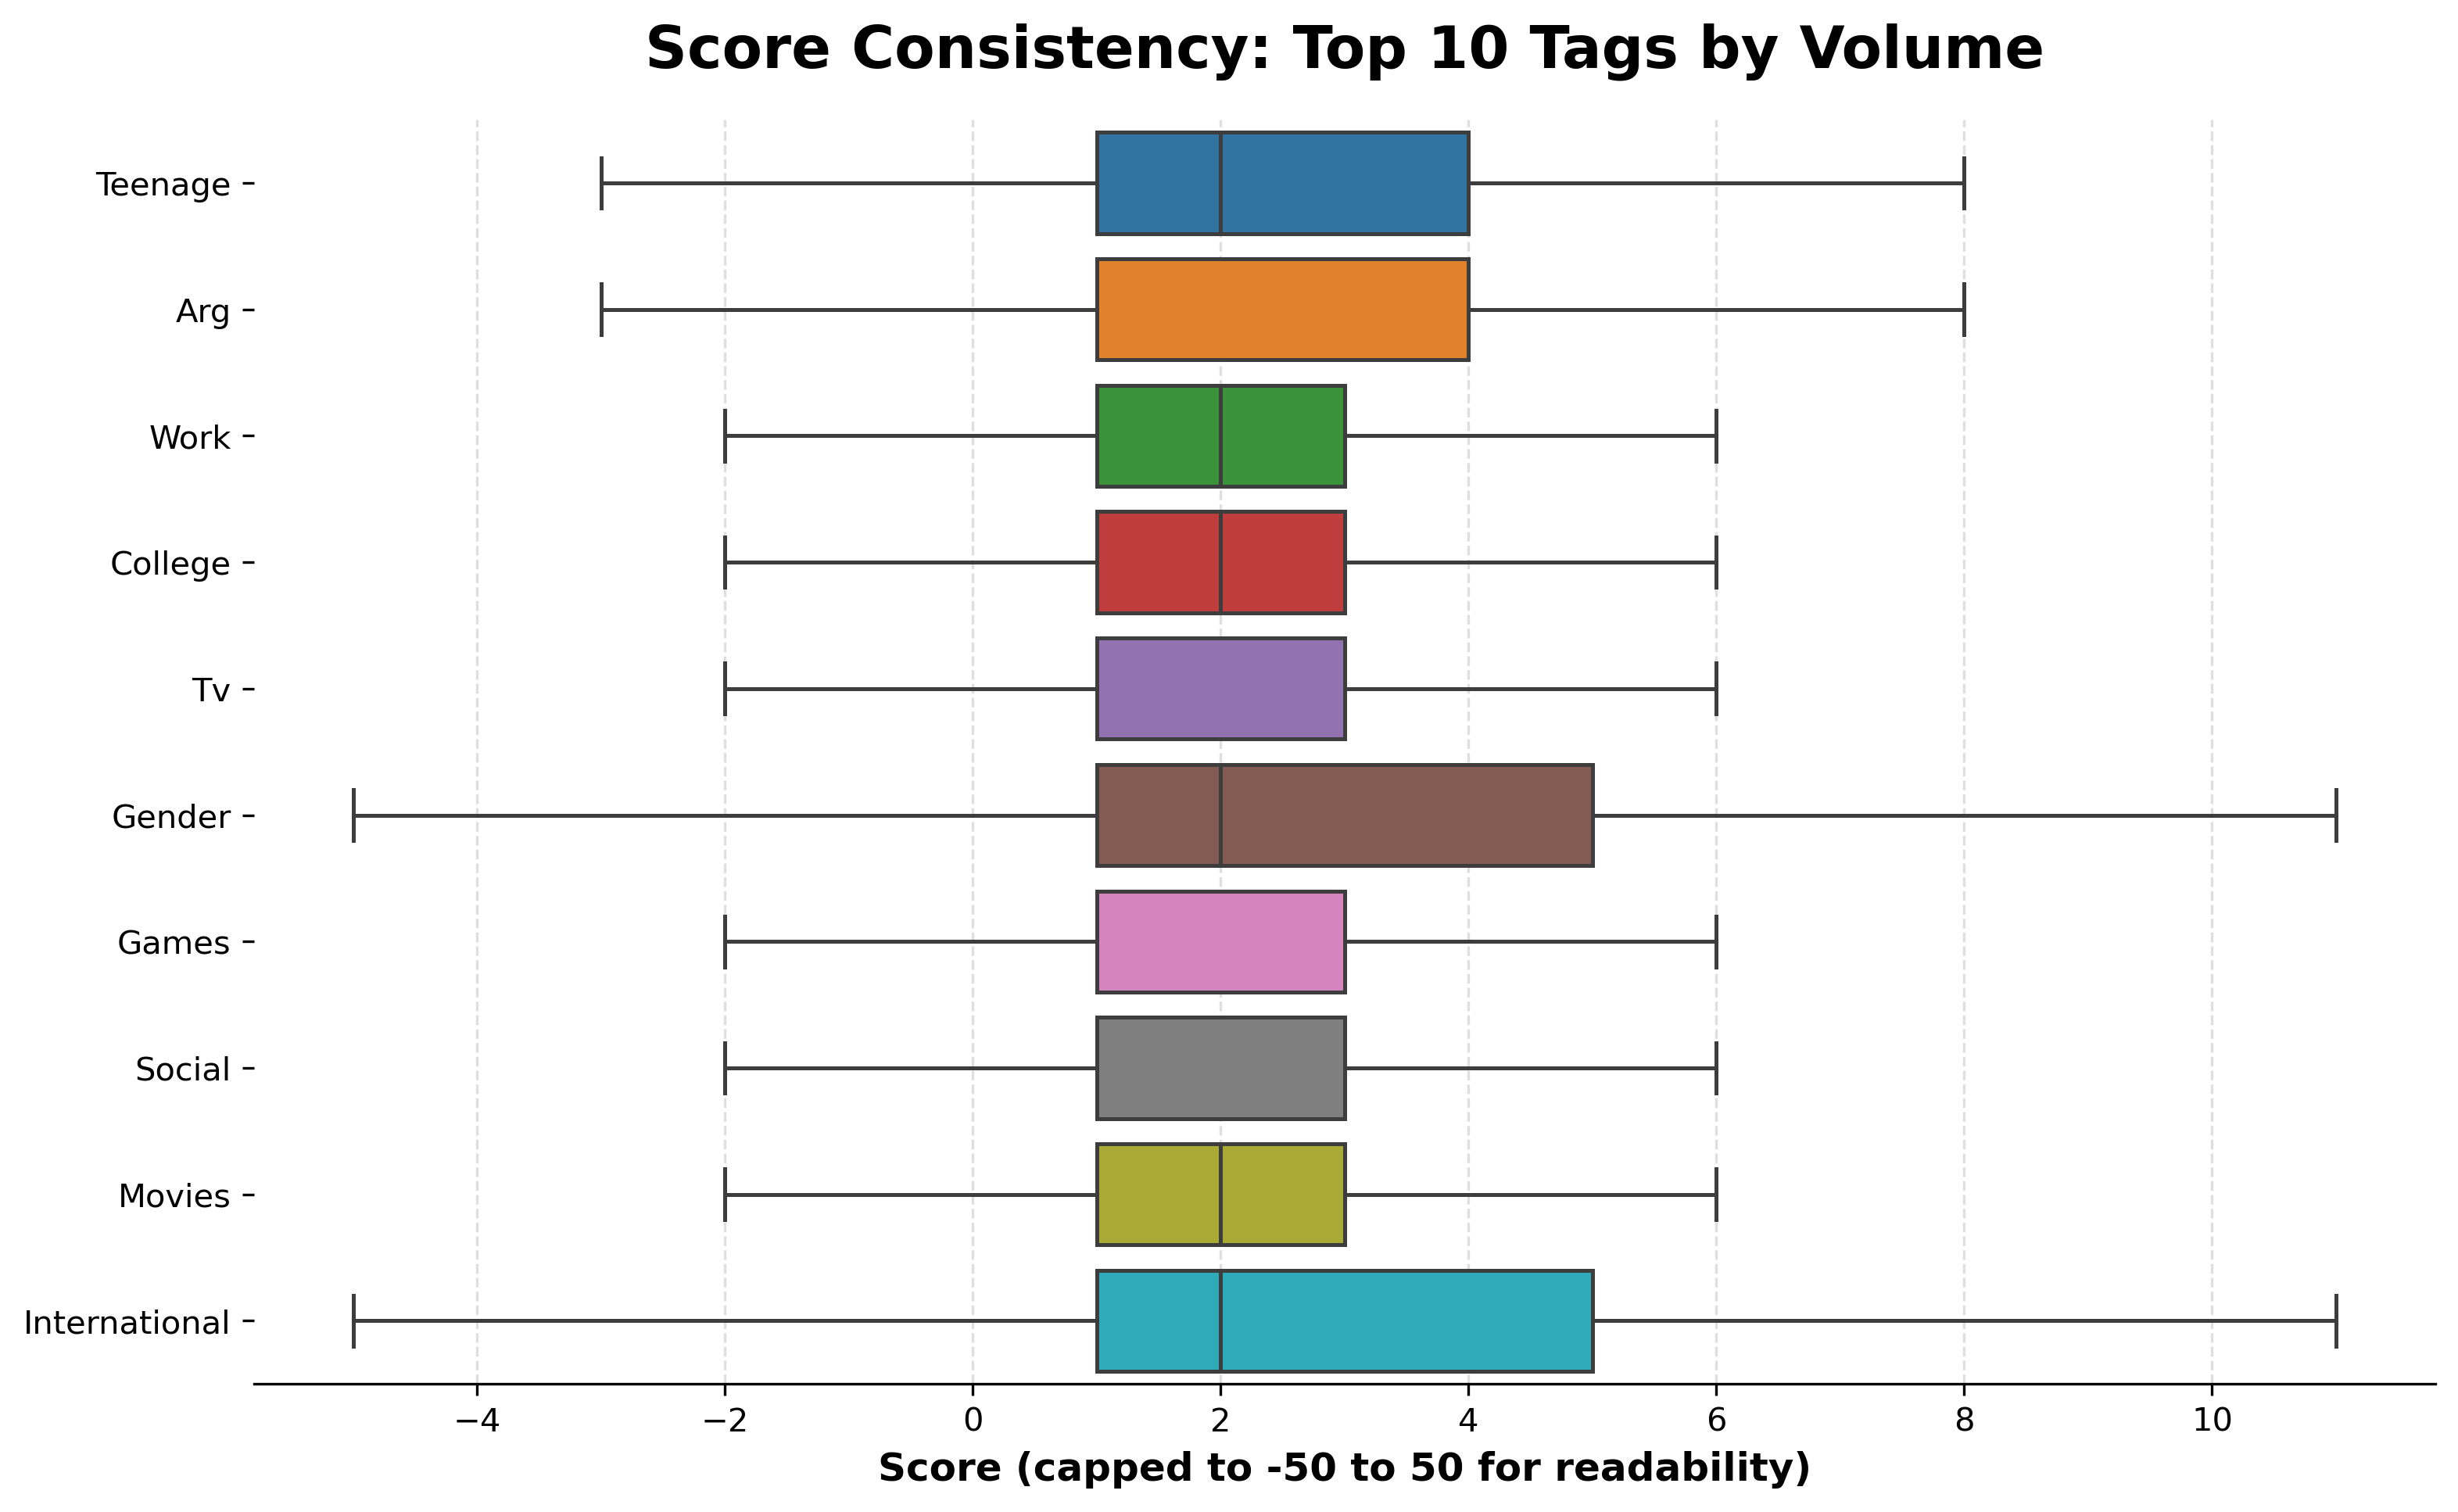

In [8]:
# Top 10 tags by post count for stability comparison
top10_tags = sample['Tag'].value_counts().head(10).index

top10_data = sample[sample['Tag'].isin(top10_tags)].copy()
top10_data['score_capped'] = top10_data['score'].clip(lower=-50, upper=50)

fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

sns.boxplot(
    data=top10_data,
    x='score_capped',
    y='Tag',
    order=top10_tags,
    ax=ax,
    showfliers=False,
    linewidth=1.2
)

ax.set_title('Score Consistency: Top 10 Tags by Volume', fontsize=18, fontweight='bold', pad=16)
ax.set_xlabel('Score (capped to -50 to 50 for readability)', fontsize=12, fontweight='bold')
ax.set_ylabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

fig.savefig('tag_stability_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Tag Stability Check

- This boxplot compares score spread across the 10 most common tags. The goal is not just to see which tags score higher, but which ones do so more consistently.

- Most tags have a similar median and a tight central range, which supports the earlier finding that typical engagement stays low across topics. The main differences appear in the tails — some tags show wider spread and more extreme positive or negative scores, making them less predictable.

- To keep the chart readable, scores are capped between -50 and 50. This does not change the ranking logic, but it prevents a small number of extreme outliers from compressing the full view.

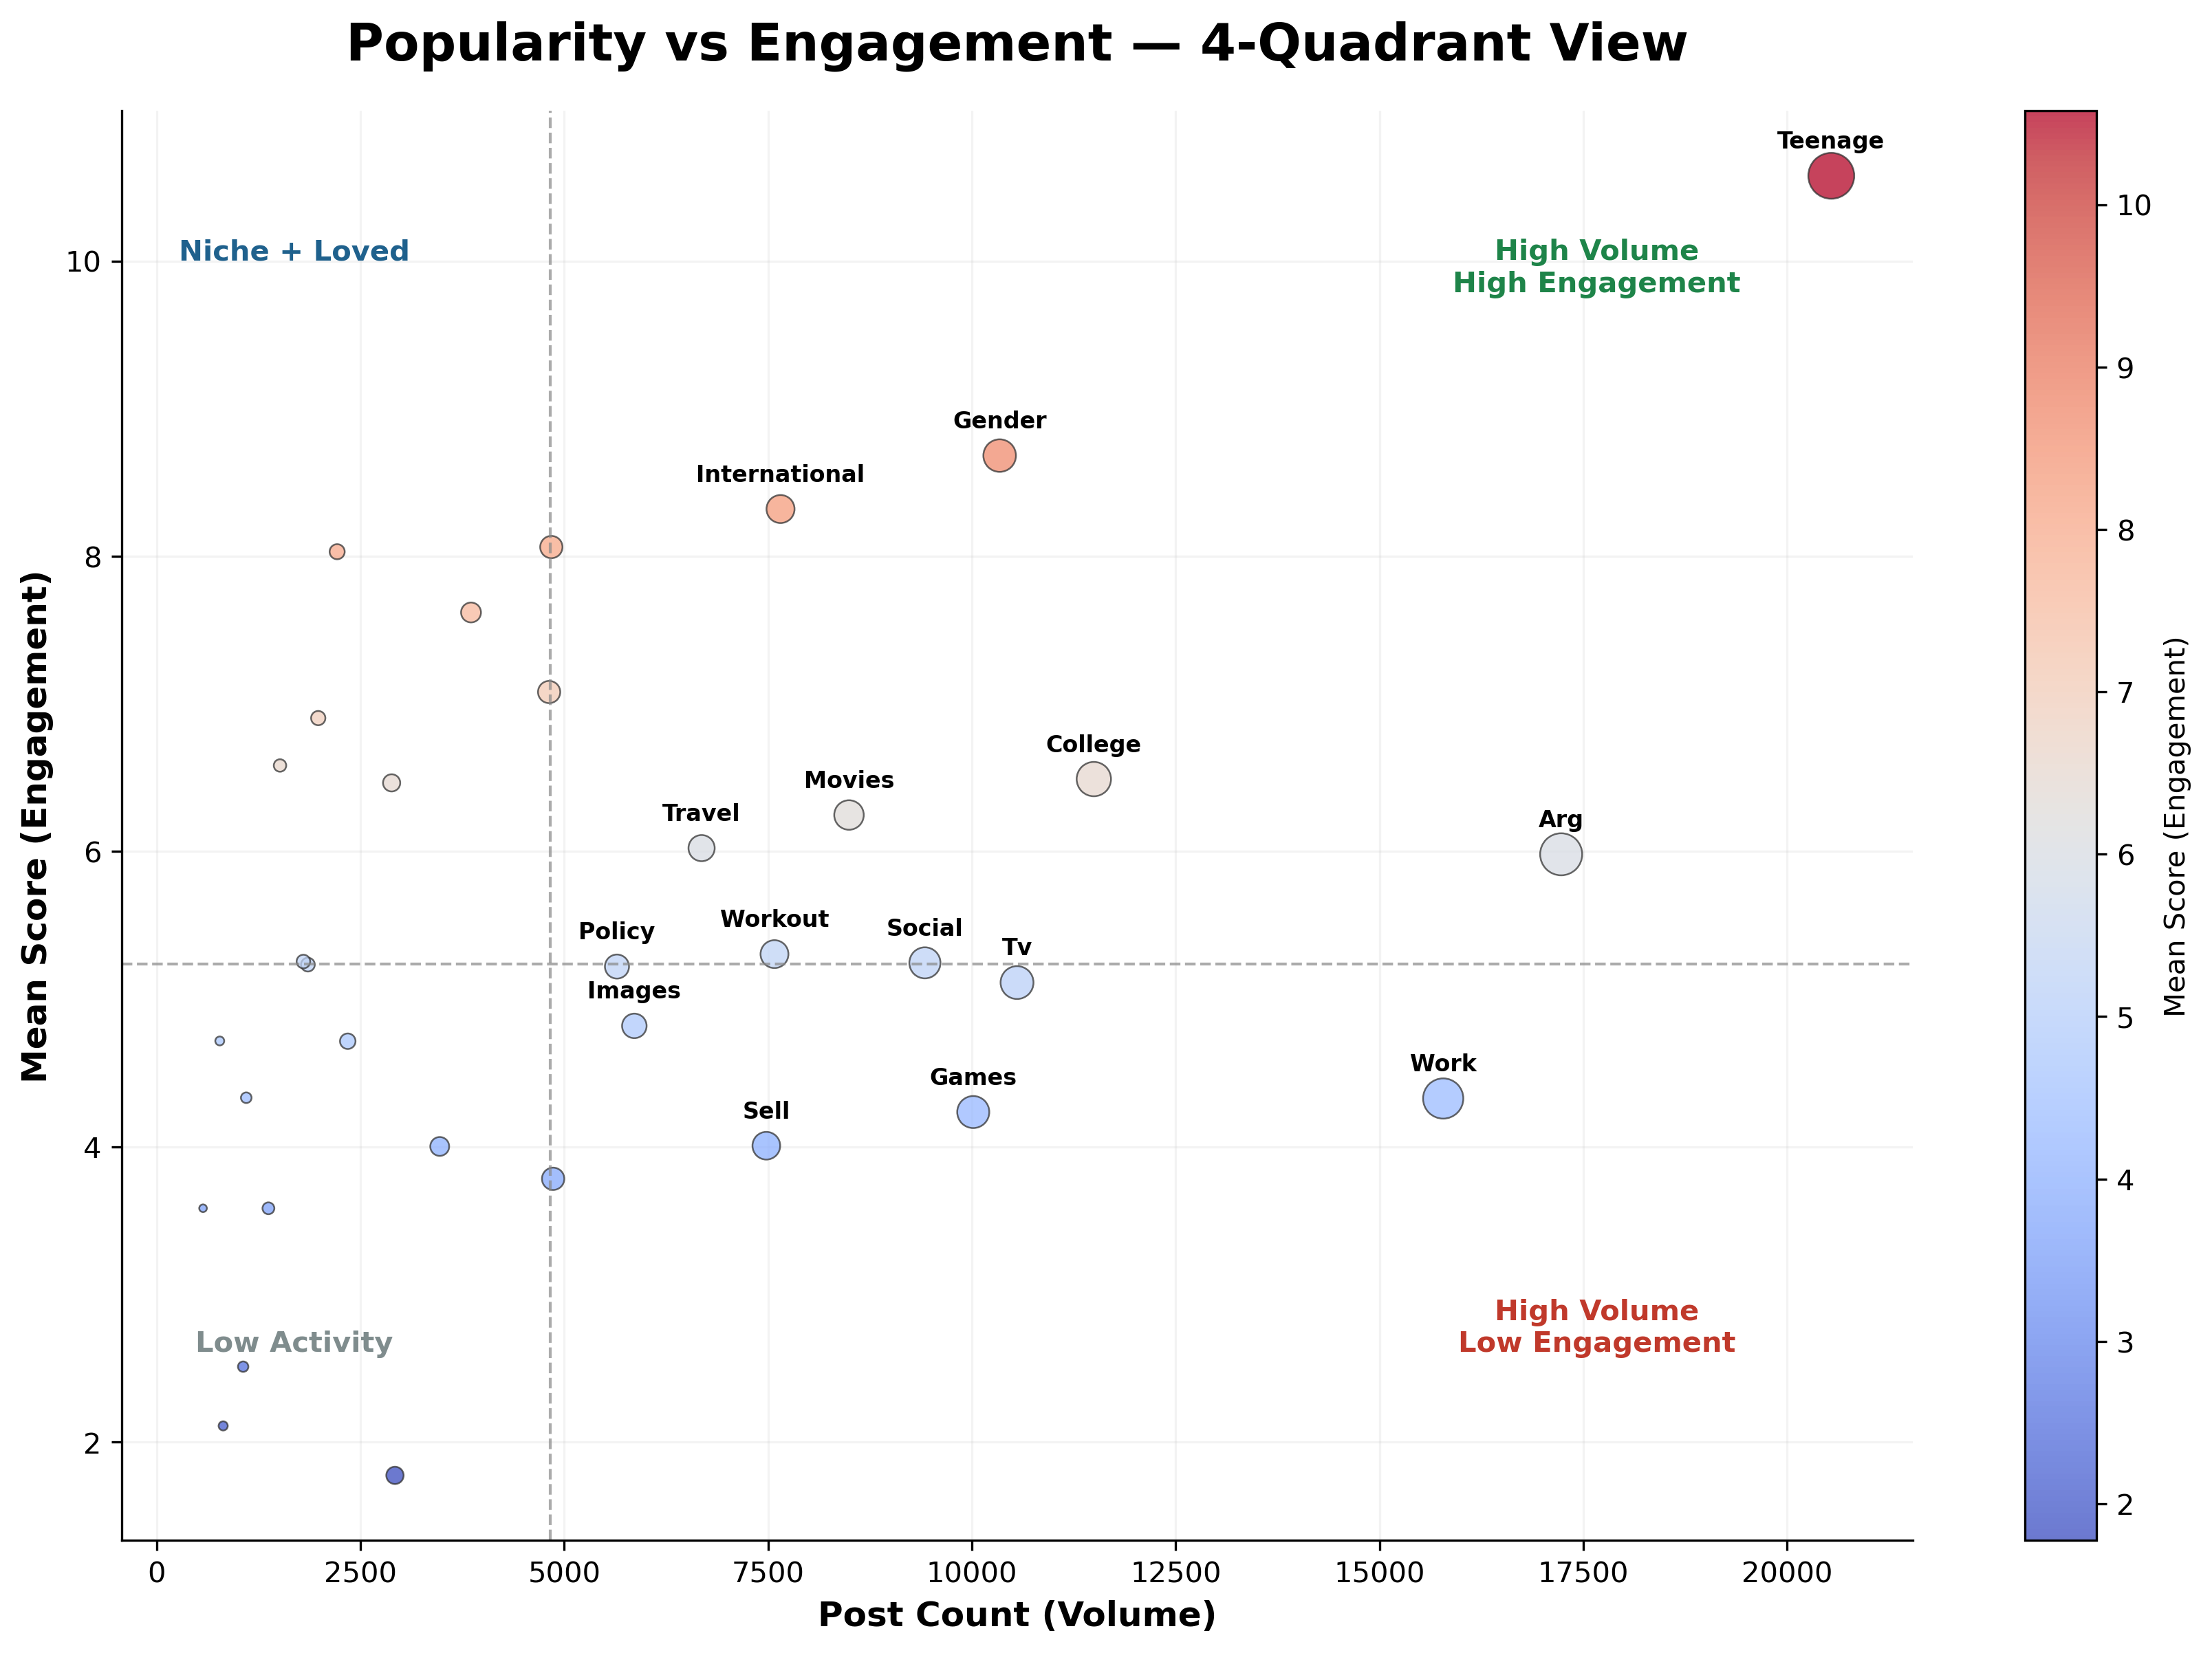

In [9]:
# Build quadrant data: volume vs engagement per tag (500+ posts only)
quad_data = sample.groupby('Tag').agg(
    post_count=('score', 'count'),
    mean_score=('score', 'mean')
).reset_index()

quad_data = quad_data[quad_data['post_count'] >= 500]

# Quadrant dividers
freq_mid = quad_data['post_count'].median()
score_mid = quad_data['mean_score'].median()

fig, ax = plt.subplots(figsize=(14, 9), dpi=300)

# Scatter plot (color = engagement, size = volume)
sc = ax.scatter(
    quad_data['post_count'],
    quad_data['mean_score'],
    s=quad_data['post_count'] / 80,
    c=quad_data['mean_score'],
    cmap='coolwarm',
    alpha=0.75,
    edgecolors='#333333',
    linewidth=0.6
)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Mean Score (Engagement)', fontsize=10)

# Label only top 15 tags to keep chart readable
top_labels = quad_data.nlargest(15, 'post_count')['Tag'].values
for _, row in quad_data.iterrows():
    if row['Tag'] in top_labels:
        ax.annotate(row['Tag'], (row['post_count'], row['mean_score']),
                    fontsize=8, fontweight='bold', ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points')

# Quadrant lines
ax.axhline(score_mid, color='#888888', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(freq_mid, color='#888888', linestyle='--', linewidth=1, alpha=0.7)

# Quadrant labels (darker colors for readability)
ax.text(quad_data['post_count'].max() * 0.86, quad_data['mean_score'].max() * 0.96,
        'High Volume\nHigh Engagement', fontsize=10, fontweight='bold',
        color='#1e8449', ha='center', va='top')

ax.text(quad_data['post_count'].max() * 0.86, quad_data['mean_score'].min() + 0.8,
        'High Volume\nLow Engagement', fontsize=10, fontweight='bold',
        color='#c0392b', ha='center', va='bottom')

ax.text(freq_mid * 0.35, quad_data['mean_score'].max() * 0.96,
        'Niche + Loved', fontsize=10, fontweight='bold',
        color='#1f618d', ha='center', va='top')

ax.text(freq_mid * 0.35, quad_data['mean_score'].min() + 0.8,
        'Low Activity', fontsize=10, fontweight='bold',
        color='#7f8c8d', ha='center', va='bottom')

# Titles and labels
ax.set_title('Popularity vs Engagement — 4-Quadrant View', fontsize=18, fontweight='bold', pad=18)
ax.set_xlabel('Post Count (Volume)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Score (Engagement)', fontsize=12, fontweight='bold')

# Clean styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.15)
ax.set_axisbelow(True)

# Save and show
fig.savefig('popularity_vs_engagement_quadrant.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Classify tags into quadrants
quad_groups = {
    "High Volume + High Engagement": [],
    "High Volume + Low Engagement": [],
    "Niche + Loved": [],
    "Low Activity": []
}

for _, row in quad_data.iterrows():
    if row['post_count'] >= freq_mid and row['mean_score'] >= score_mid:
        quad_groups["High Volume + High Engagement"].append(row['Tag'])
    elif row['post_count'] >= freq_mid:
        quad_groups["High Volume + Low Engagement"].append(row['Tag'])
    elif row['mean_score'] >= score_mid:
        quad_groups["Niche + Loved"].append(row['Tag'])
    else:
        quad_groups["Low Activity"].append(row['Tag'])

# Print clean summary
print("\n--- Quadrant Summary ---\n")

for k, v in quad_groups.items():
    print(f"{k}:")
    print(", ".join(v))
    print()


--- Quadrant Summary ---

High Volume + High Engagement:
Arg, College, Gender, International, Movies, Nature, Social, Teenage, Travel, Workout

High Volume + Low Engagement:
Games, Guns, Images, Policy, Sell, Tv, Work

Niche + Loved:
Comments, Media, Music, Photography, Sports, Stats, Treatment

Low Activity:
Conversation, Fashion, Food, Hardware, Info, Laptops, Mobile, Pets, Religion, Spanish



## Popularity vs Engagement

This chart puts posting volume and average engagement side by side. The dashed lines mark the median of each axis, splitting tags into four groups.

- Top-right: high volume and high engagement — these are the strongest tags
- Bottom-right: high volume but low engagement — people post a lot, but response is weak
- Top-left: lower volume but strong engagement — smaller tags with loyal interest
- Bottom-left: low volume and low engagement — lowest priority

The bottom-right group matters most for business. These tags attract a lot of activity but do not create much response, which makes them the best place to investigate what is going wrong.

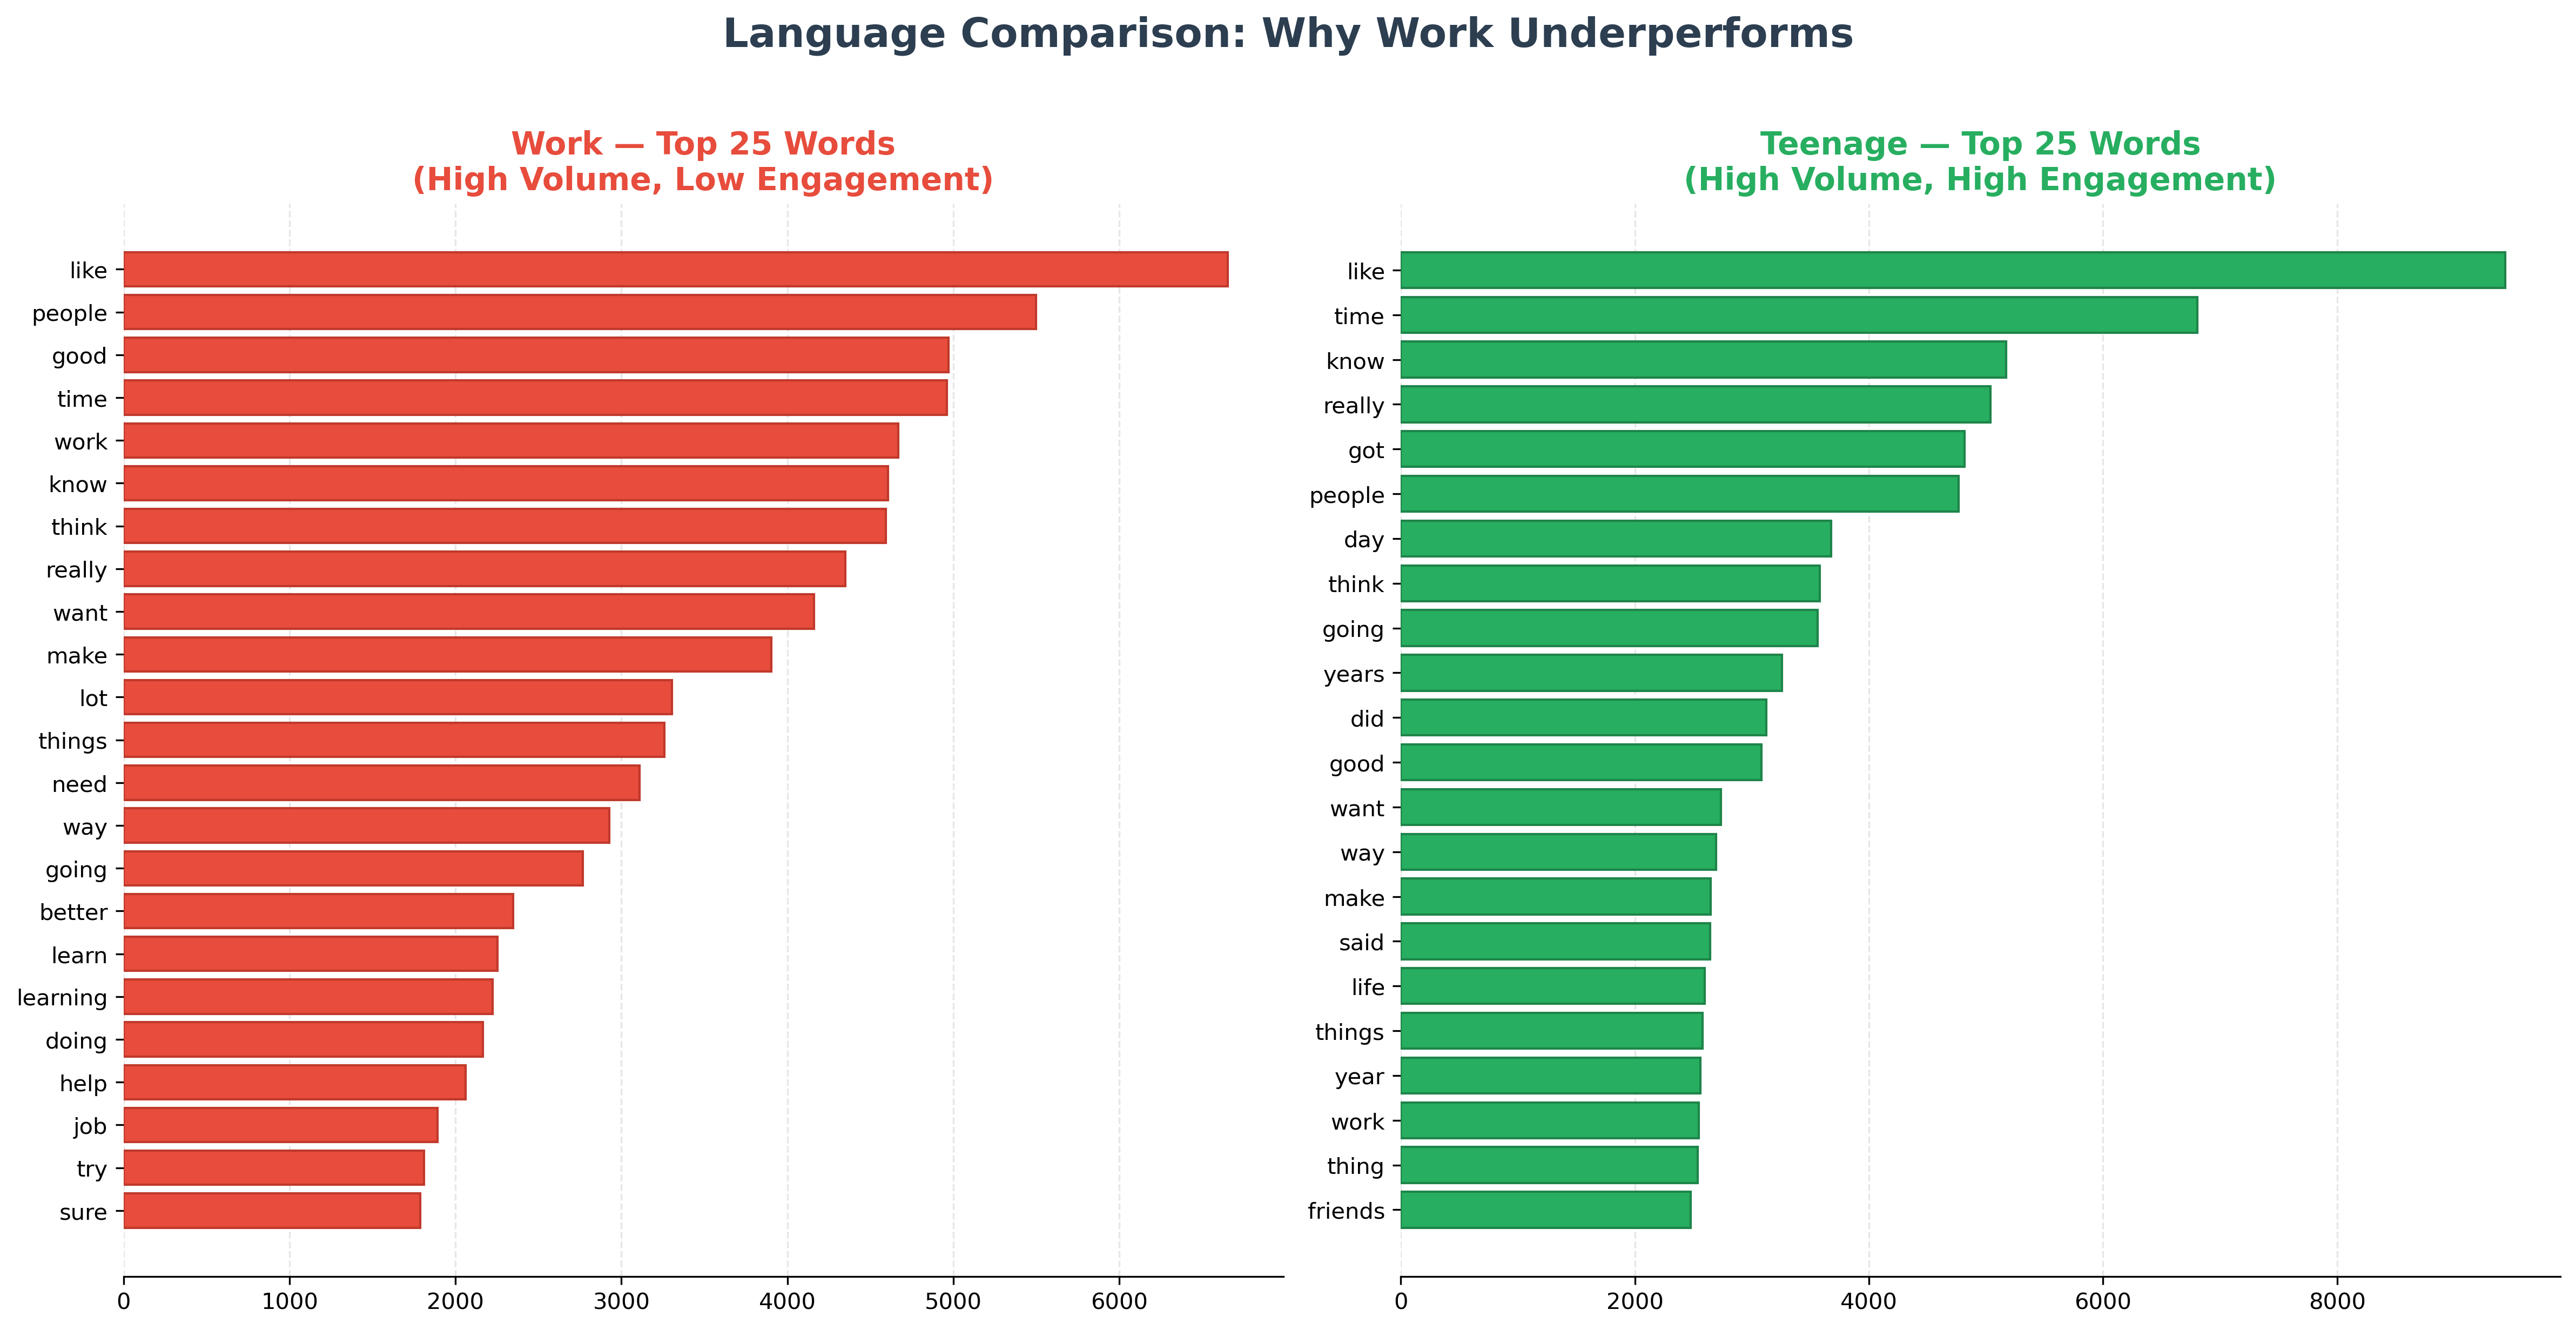

In [11]:
work_text = sample.loc[sample['Tag'] == 'Work', 'body'].dropna().astype(str).str.lower()
teen_text = sample.loc[sample['Tag'] == 'Teenage', 'body'].dropna().astype(str).str.lower()

custom_stopwords = {
    'don', 'didn', 'doesn', 'isn', 'aren', 'wasn', 'weren',
    'won', 'wouldn', 'couldn', 'shouldn', 'hasn', 'haven',
    'hadn', 'll', 've', 'im', 'ive', 'youre', 'theyre', 'just'
}

def get_top_words(text_series, n=25):
    vec = CountVectorizer(
        stop_words='english',
        max_features=n,
        token_pattern=r'(?u)\b[a-zA-Z]{3,}\b'
    )
    matrix = vec.fit_transform(text_series)

    word_counts = pd.DataFrame({
        'word': vec.get_feature_names_out(),
        'count': matrix.sum(axis=0).A1
    })

    word_counts = word_counts[~word_counts['word'].isin(custom_stopwords)]
    return word_counts.sort_values('count', ascending=False).head(n)

work_words = get_top_words(work_text)
teen_words = get_top_words(teen_text)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), dpi=300)

ax1.barh(work_words['word'], work_words['count'], color='#e74c3c', edgecolor='#c0392b')
ax1.set_title('Work — Top 25 Words\n(High Volume, Low Engagement)', fontsize=14, fontweight='bold', color='#e74c3c')
ax1.invert_yaxis()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.xaxis.grid(True, linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)

ax2.barh(teen_words['word'], teen_words['count'], color='#27ae60', edgecolor='#1e8449')
ax2.set_title('Teenage — Top 25 Words\n(High Volume, High Engagement)', fontsize=14, fontweight='bold', color='#27ae60')
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.xaxis.grid(True, linestyle='--', alpha=0.3)
ax2.set_axisbelow(True)

plt.suptitle('Language Comparison: Why Work Underperforms', fontsize=18, fontweight='bold', y=1.02, color='#2c3e50')
plt.tight_layout()
fig.savefig('work_vs_teenage_words.png', dpi=300, bbox_inches='tight')
plt.show()

## Deep Dive: Why "Work" Underperforms

- Work is one of the most talked-about tags, but its engagement is relatively weak. The quadrant chart placed it in the high-volume, low-engagement group, making it a good case for deeper analysis.

- Work posts use more practical and general words such as "work," "job," "people," and "time." In contrast, Teenage posts include more personal and day-to-day language like "know," "really," "day," and "years."

- This does not prove why one tag performs better, but it suggests that higher-engagement posts may feel more personal and relatable, while Work posts tend to be more factual and routine.

High engagement posts (top 10%, score >= 8): 22,651
Low engagement posts (bottom 50%, score <= 2): 136,327


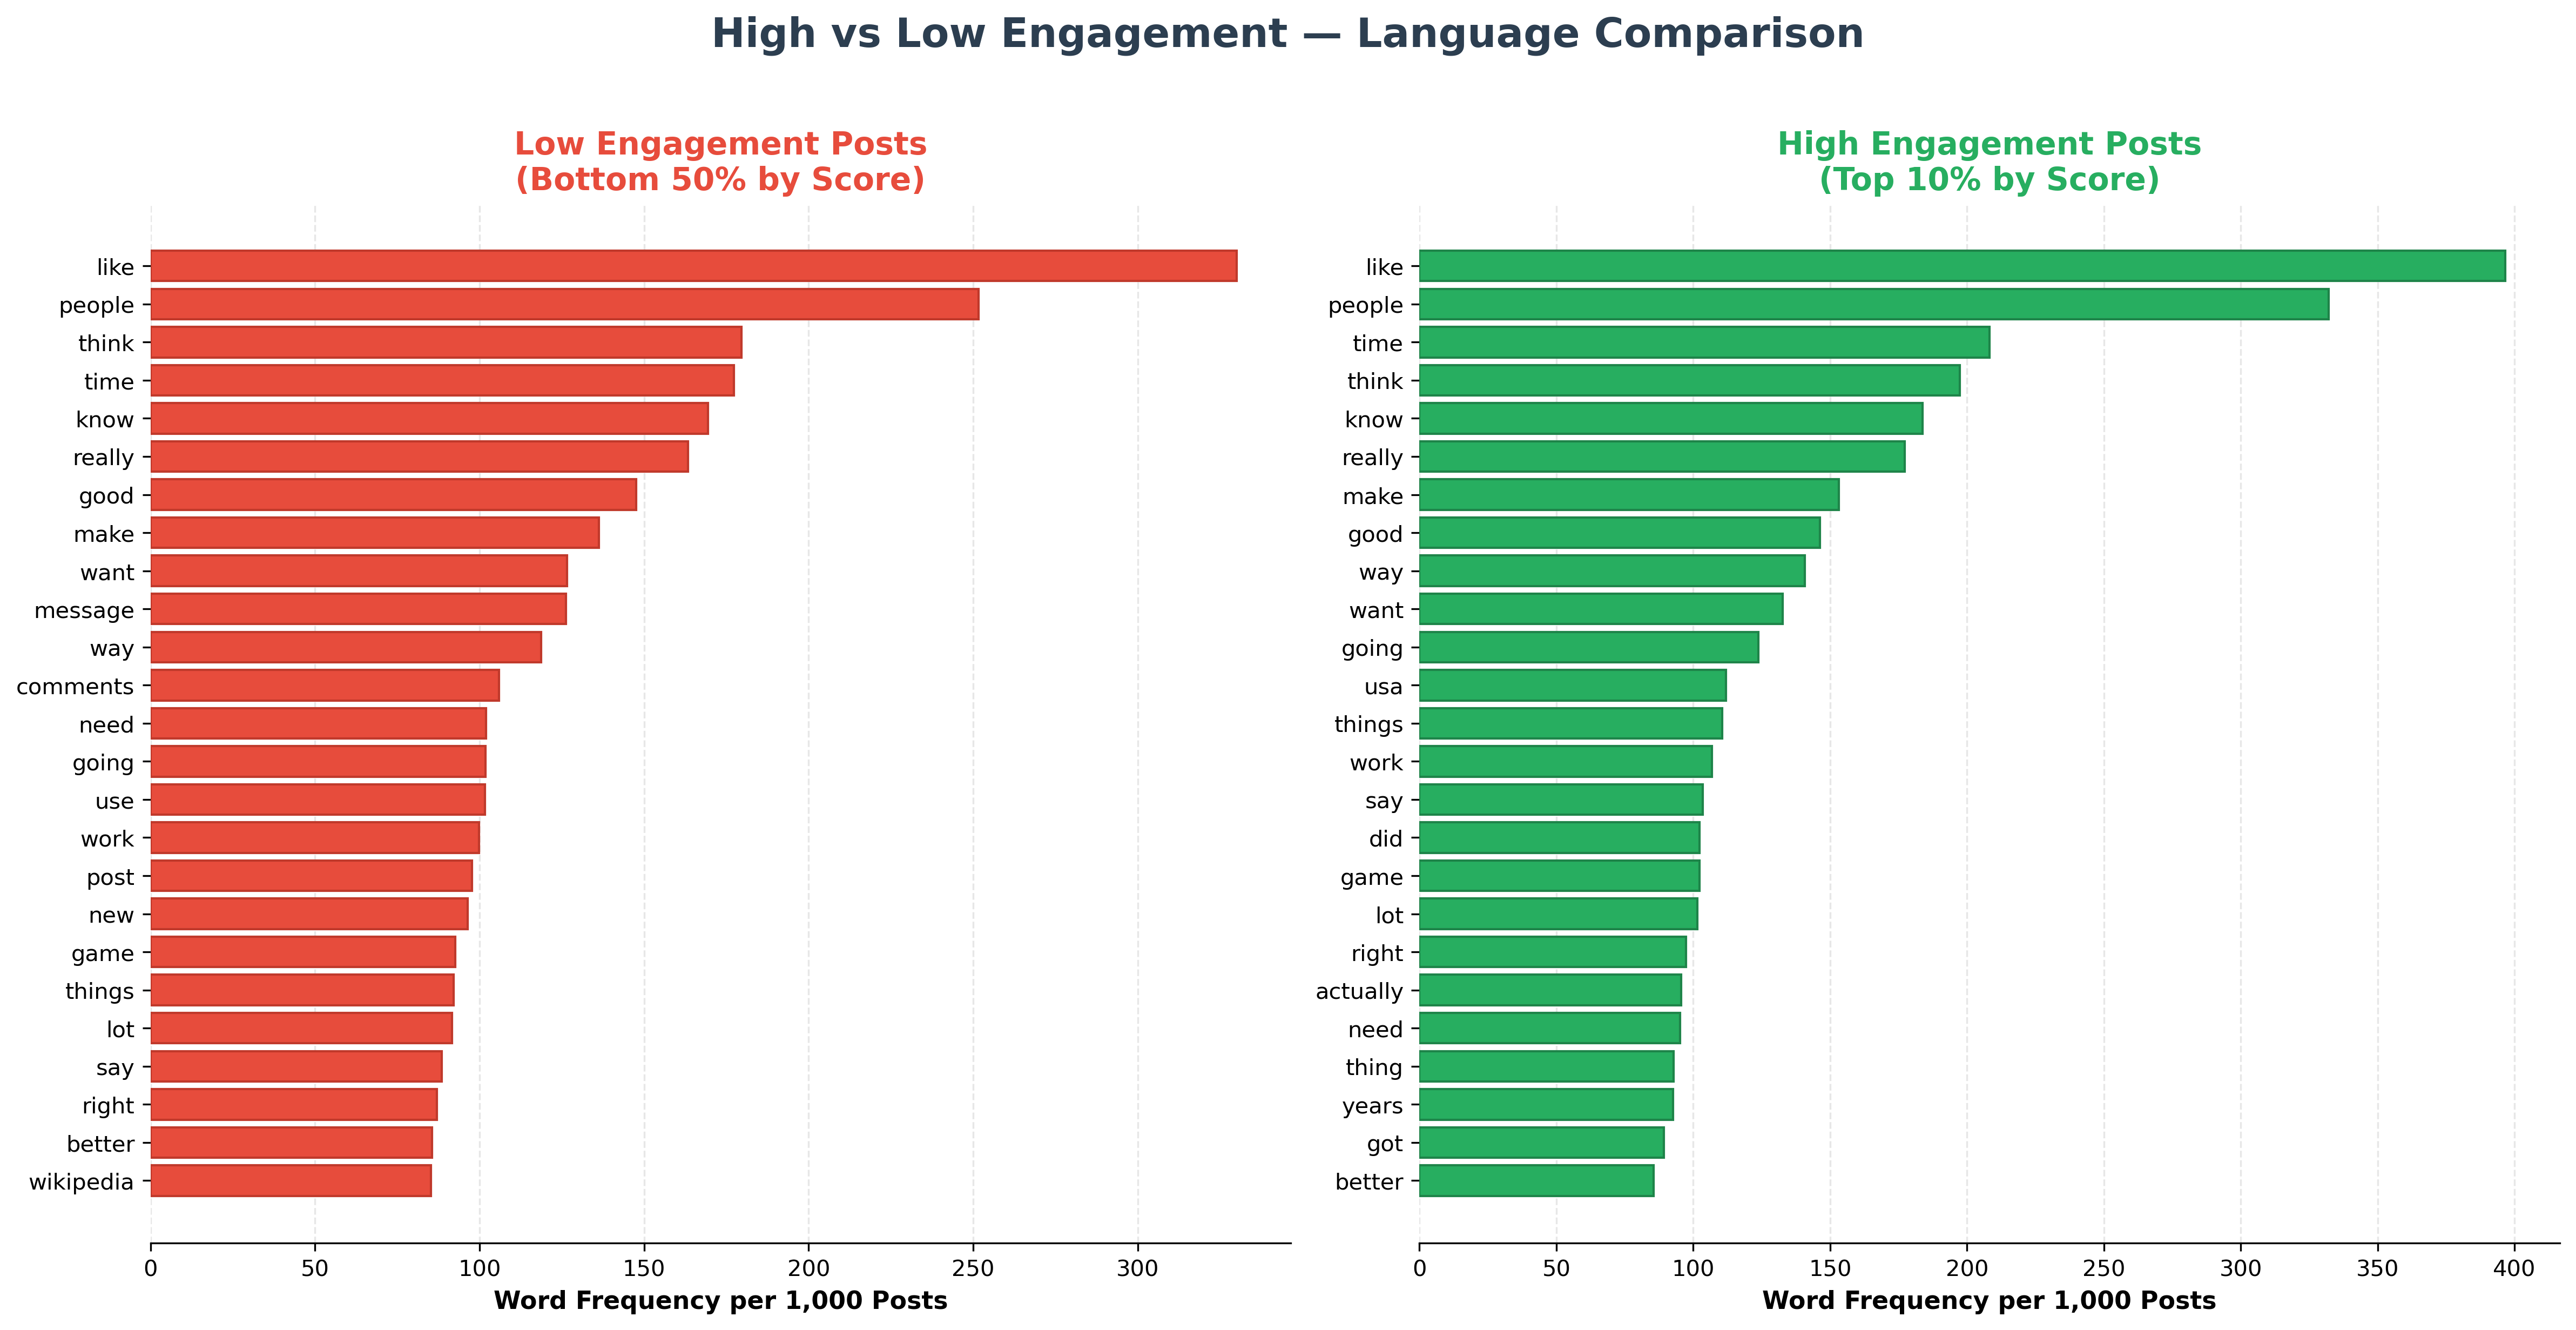

In [12]:
# Split ALL posts into high-engagement and low-engagement groups
score_90 = sample['score'].quantile(0.90)
score_50 = sample['score'].quantile(0.50)

high_eng = sample.loc[sample['score'] >= score_90, 'body'].dropna().astype(str).str.lower()
low_eng = sample.loc[sample['score'] <= score_50, 'body'].dropna().astype(str).str.lower()

print(f"High engagement posts (top 10%, score >= {score_90:.0f}): {len(high_eng):,}")
print(f"Low engagement posts (bottom 50%, score <= {score_50:.0f}): {len(low_eng):,}")

custom_stopwords = {
    'don', 'didn', 'doesn', 'isn', 'aren', 'wasn', 'weren',
    'won', 'wouldn', 'couldn', 'shouldn', 'hasn', 'haven',
    'hadn', 'll', 've', 'im', 'ive', 'youre', 'theyre',
    'http', 'https', 'www', 'com', 'org', 'amp', 'reddit', 'wiki','just'
}

def get_top_words_normalized(text_series, n=25):
    vec = CountVectorizer(
        stop_words='english',
        token_pattern=r'(?u)\b[a-zA-Z]{3,}\b'
    )
    matrix = vec.fit_transform(text_series)

    word_counts = pd.DataFrame({
        'word': vec.get_feature_names_out(),
        'count': matrix.sum(axis=0).A1
    })

    word_counts = word_counts[~word_counts['word'].isin(custom_stopwords)].copy()

    # Normalize by number of posts so groups are comparable
    word_counts['rate_per_1000_posts'] = (word_counts['count'] / len(text_series)) * 1000

    return word_counts.sort_values('rate_per_1000_posts', ascending=False).head(n)

high_words = get_top_words_normalized(high_eng, n=25)
low_words = get_top_words_normalized(low_eng, n=25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), dpi=300)

# Low engagement
ax1.barh(low_words['word'], low_words['rate_per_1000_posts'], color='#e74c3c', edgecolor='#c0392b')
ax1.set_title('Low Engagement Posts\n(Bottom 50% by Score)', fontsize=14, fontweight='bold', color='#e74c3c')
ax1.invert_yaxis()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.xaxis.grid(True, linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.set_xlabel('Word Frequency per 1,000 Posts', fontsize=11, fontweight='bold')

# High engagement
ax2.barh(high_words['word'], high_words['rate_per_1000_posts'], color='#27ae60', edgecolor='#1e8449')
ax2.set_title('High Engagement Posts\n(Top 10% by Score)', fontsize=14, fontweight='bold', color='#27ae60')
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.xaxis.grid(True, linestyle='--', alpha=0.3)
ax2.set_axisbelow(True)
ax2.set_xlabel('Word Frequency per 1,000 Posts', fontsize=11, fontweight='bold')

plt.suptitle('High vs Low Engagement — Language Comparison', fontsize=18, fontweight='bold', y=1.02, color='#2c3e50')
plt.tight_layout()
fig.savefig('high_vs_low_engagement_words.png', dpi=300, bbox_inches='tight')
plt.show()

## High vs Low Engagement — Language Comparison

- This section compares language across all posts, not just within one tag. Posts are split into two groups: top 10% by score and bottom 50% by score.

- The goal is not to prove what causes engagement, but to check whether high-scoring posts use clearly different words. Word frequencies are normalized by group size so the comparison stays fair.

- The results show that the most common words are largely similar across both groups. This suggests that engagement is not driven by specific keywords alone, but likely depends on context, phrasing, or how ideas are expressed.

In [13]:
# Assign quadrants
quad_data['quadrant'] = quad_data.apply(
    lambda row:
    'High Volume + High Engagement' if row['post_count'] >= freq_mid and row['mean_score'] >= score_mid
    else 'High Volume + Low Engagement' if row['post_count'] >= freq_mid and row['mean_score'] < score_mid
    else 'Niche + Loved' if row['post_count'] < freq_mid and row['mean_score'] >= score_mid
    else 'Low Activity',
    axis=1
)

# Merge median and IQR
summary = quad_data.merge(
    tag_stats[['Tag', 'median_score', 'iqr']],
    on='Tag',
    how='left'
)

# Define quadrant order (business priority)
quadrant_order = {
    'High Volume + High Engagement': 1,
    'Niche + Loved': 2,
    'High Volume + Low Engagement': 3,
    'Low Activity': 4
}

summary['quadrant_rank'] = summary['quadrant'].map(quadrant_order)

# Sort properly: first by quadrant, then by mean score (descending)
summary = summary.sort_values(
    by=['quadrant_rank', 'mean_score'],
    ascending=[True, False]
)

# Final clean table
summary_display = summary[
    ['Tag', 'post_count', 'median_score', 'mean_score', 'iqr', 'quadrant']
].copy()

summary_display.columns = [
    'Tag',
    'Posts',
    'Median Score',
    'Mean Score',
    'IQR',
    'Quadrant'
]

# Display
print(f"Total tags (500+ posts): {len(summary_display)}\n")
summary_display.round(2)

Total tags (500+ posts): 34



,Tag,Posts,Median Score,Mean Score,IQR,Quadrant
28,Teenage,20541,2.0,10.58,3.0,High Volume + High Engagement
7,Gender,10341,2.0,8.68,4.0,High Volume + High Engagement
12,International,7653,2.0,8.32,4.0,High Volume + High Engagement
18,Nature,4842,2.0,8.06,3.0,High Volume + High Engagement
1,College,11496,2.0,6.49,2.0,High Volume + High Engagement
16,Movies,8493,2.0,6.25,2.0,High Volume + High Engagement
29,Travel,6685,2.0,6.02,2.0,High Volume + High Engagement
0,Arg,17228,1.0,5.98,3.0,High Volume + High Engagement
33,Workout,7579,2.0,5.31,2.0,High Volume + High Engagement
24,Social,9424,1.0,5.25,2.0,High Volume + High Engagement


## Final Summary — Tag Performance Overview

This table brings together volume, engagement, and consistency for each tag. Tags are grouped into four categories based on their position in the popularity vs engagement framework.

- High Volume + High Engagement: Strong performers — these topics consistently drive both activity and response.
- Niche + Loved: Smaller but highly engaging — good candidates for growth.
- High Volume + Low Engagement: High activity but weak response — these need content or positioning changes.
- Low Activity: Low on both volume and engagement — lowest priority unless there is a specific use case.

Within each group, tags are sorted by mean score so the strongest performers appear at the top.

# Recommendations

Based on the analysis, four actions for any community or content platform:

**1. Double down on high-engagement topics**  
Tags like Teenage, Gender, and International consistently show strong engagement. These topics should get more visibility, better moderation, and priority placement in feeds or recommendations.

**2. Investigate high-volume, low-engagement topics**  
Tags like Work, Games, and TV attract a lot of posts but receive relatively low engagement. The language analysis suggests these posts are more practical and less personal. Encouraging more opinion-driven or experience-based content in these areas may improve engagement.

**3. Nurture niche-but-loved topics**  
Tags like Photography, Nature, and Treatment have smaller audiences but strong reactions. These are growth opportunities — promoting them to wider audiences could bring in engaged users without reducing content quality.

**4. Focus on how content is written, not just what it's about**  
The language comparison shows that common words appear in both high and low engagement posts. This suggests that keywords alone do not explain performance — how ideas are expressed likely plays a role alongside topic selection.

---

# Limitations

- **Score is not sentiment.** Reddit upvotes reflect popularity or agreement, not whether the content is positive or negative.
- **Dataset is pre-labeled.** Tag and Topic values were assigned beforehand, so they reflect existing categorization rather than patterns discovered in this analysis.
- **Score doesn't capture full engagement.** Comments, shares, saves, and other interactions are not included.
- **Sample vs population.** Analysis was performed on a 200K sample from 4.3M rows. Validation shows it represents the overall data, but smaller edge cases may be missed.
- **No time dimension.** Without timestamps, changes in engagement over time cannot be analyzed.

----

# Conclusion

Most Reddit posts get almost no attention — the median score is 2, and 90% of posts score 8 or below. The few posts that do well tend to come from the same handful of topics.

The biggest problem area is tags like Work and Games — people post a lot but nobody really reacts. When you look at the language, it makes sense. These posts are plain and factual. The tags that do well (like Teenage and Gender) have posts that feel more personal — people share opinions, tell stories, and write with emotion.

For any platform trying to improve engagement, the answer isn't just picking the right topic. It's about how people write. Posts that feel personal get more reaction than posts that just share information.

---